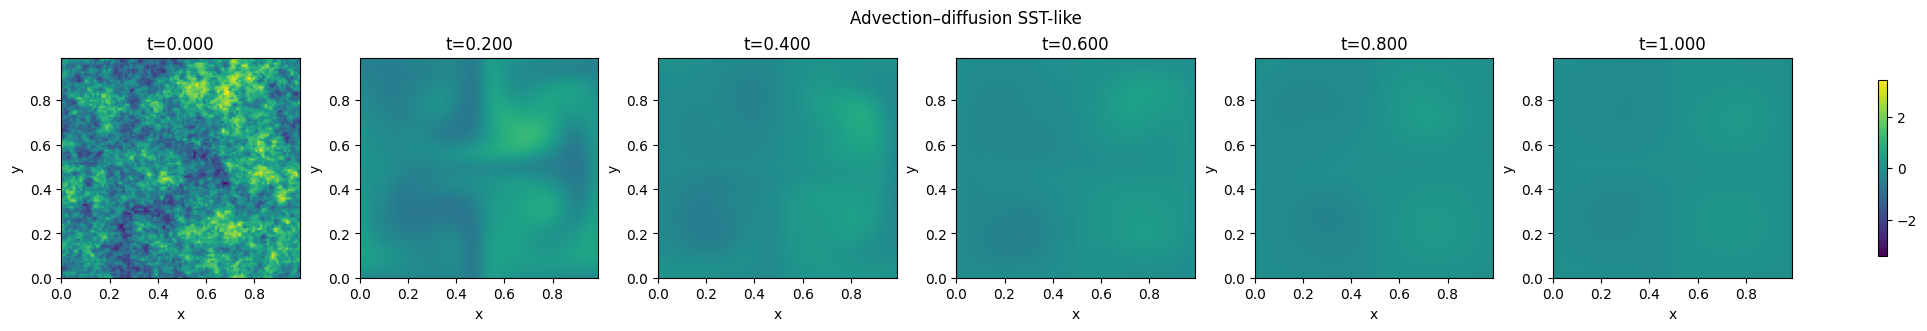

In [11]:
from numerical_solver import lowpass_random_field, create_visualisation
from numerical_solver import AdvDiffSpectralSL2D  # if you put it in same file

nx=101; ny=101; Lx=1.0; Ly=1.0
kappa = 0.01
nt=101; t0=0.0; t1=1.0

solver = AdvDiffSpectralSL2D(nx=nx, ny=ny, Lx=Lx, Ly=Ly, kappa=kappa)

u0 = lowpass_random_field(nx, ny, Lx, Ly, ell=10, nu=0.001, seed=0)

T, snapshots = solver.evolve(
    u0, nt=nt, t0=t0, t1=t1,
    vel_kind="taylor_green",
    U0=2.0,          # increase for stronger swirling
    vel_omega=0.0,   # try 2*np.pi for time-modulated flow
    forcing="smooth_random",
    forcing_amp=0.01,
    forcing_rho=0.995,
    seed=0,
)

X, Y = solver.X, solver.Y
fig = create_visualisation(X, Y, snapshots, T, n_indices=6, title="Advection–diffusion SST-like")

In [11]:
import pickle
import os
import numpy as np

# Get the current working directory
save_path = os.path.join(os.getcwd(), 'numerical_data.pkl')
U = np.stack(snapshots, axis=0)   # shape (nt, ny, nx)
# Save variables to a pickle file
data = {'X': X, 'Y': Y, 'U': U, 'T': T}
with open(save_path, 'wb') as f:
    pickle.dump(data, f)

print(f"Variables saved to {save_path}")

Variables saved to c:\Users\darsh\Documents\fyp\myfyp\advection_diffusion\time_in_encoders_only\numerical_data.pkl
